# kNN for Perturbation Response Prediction (state-aware)

## What this notebook does

Two purposes:

1. **BENCHMARK.** Evaluate k-nearest-neighbors regression on TF embeddings for predicting
   perturbation responses, using TFs with Marson 2025 Perturb-seq ground truth. 5-fold CV:
   train kNN on 80% of TFs, predict the held-out 20%, compare to **real** log2FC vectors.
   Same protocol as Cole et al. (2026) so numbers are directly comparable to theirs.

2. **APPLY.** Once kNN is validated, predict perturbation responses for the ~649 TFs that
   were NOT in Marson 2025. These become a fourth network layer (perturb-net-predicted)
   filling the gap in perturb-net.

## State-aware structure

The perturb-net is split by culture condition: **Rest** and **Stim8hr**. (Stim48hr is
available but we skip it here — 8hr is the cleaner acute-activation signal and matches
the project's rest/act framing. Can be re-added later as supplementary.) We run the
whole pipeline once per state — two benchmarks, two sets of predictions.

## Why kNN at all

Simplest possible predictor: find the k most similar TFs by embedding distance, average
their known responses. No neural net, no training, no gradient descent. Cole et al. (2026)
benchmarked 600+ models and showed kNN on the right embeddings (especially STRING-based)
is competitive with — and often beats — GEARS, CPA, scGPT fine-tuning, latent diffusion,
and flow matching. kNN here is a legitimate predictor, not a throwaway baseline.

## Reference

Cole, E., Huizing, G.-J., Addagudi, S., et al. (2026). *Foundation Models Improve
Perturbation Response Prediction.* bioRxiv. https://doi.org/10.64898/2026.02.18.706454

---

## 0. Setup

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = '/content/drive/MyDrive/benchmarking_paper/datasets'
OUT_DIR    = os.path.join(DRIVE_ROOT, 'knn_perturbation_prediction')
os.makedirs(OUT_DIR, exist_ok=True)

# Inputs: state-specific perturb-net edge tables (long format)
PERTURB_NET_DIR = os.path.join(DRIVE_ROOT, 'perturbnet_outputs')
PERTURB_NET_FILES = {
    'Rest':    os.path.join(PERTURB_NET_DIR, 'perturb_net_tfs_only_Rest_filtered.csv'),
    'Stim8hr': os.path.join(PERTURB_NET_DIR, 'perturb_net_tfs_only_Stim8hr_filtered.csv'),
}
STATES = list(PERTURB_NET_FILES.keys())

HUMAN_TFS_CSV = os.path.join(DRIVE_ROOT, 'tf_lists/humanTFs_1639_clean.csv')

# Optional — for the bonus 3-way intersection block
OVERLAP_DIR = os.path.join(DRIVE_ROOT, 'network_overlap_analysis_fixed')

print(f'OUT_DIR: {OUT_DIR}')
print(f'States: {STATES}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT_DIR: /content/drive/MyDrive/benchmarking_paper/datasets/knn_perturbation_prediction
States: ['Rest', 'Stim8hr']


In [13]:
# Single install. No numpy pin — this notebook has no scPRINT2 dependency, so we avoid
# the ABI-mismatch hassle from before.
!pip install -q scikit-learn pandas scipy matplotlib seaborn

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Bonus: three-way TF intersection for CD4 (T-net Tier 1)

Answers "how many TFs do scPRINT2, pySCENIC, AND Perturb-seq all agree on?" — the
highest-confidence set for the T-net. Adjust filenames if your overlap-analysis script
saved them under different names.

In [15]:
def load_tf_set(path, col=None):
    df = pd.read_csv(path)
    if col is None:
        col = df.columns[0]
    return set(df[col].dropna().astype(str).str.upper())

try:
    scprint_rest  = load_tf_set(os.path.join(OVERLAP_DIR, 'scPRINT2_CD4_rest_tfs.csv'))
    pyscenic_rest = load_tf_set(os.path.join(OVERLAP_DIR, 'pySCENIC_CD4_rest_tfs.csv'))
    perturb_rest  = load_tf_set(os.path.join(OVERLAP_DIR, 'Perturb-seq_CD4_rest_tfs.csv'))

    scprint_act   = load_tf_set(os.path.join(OVERLAP_DIR, 'scPRINT2_CD4_act_tfs.csv'))
    pyscenic_act  = load_tf_set(os.path.join(OVERLAP_DIR, 'pySCENIC_CD4_act_tfs.csv'))
    perturb_act8  = load_tf_set(os.path.join(OVERLAP_DIR, 'Perturb-seq_CD4_stim8hr_tfs.csv'))

    rest_3way = scprint_rest & pyscenic_rest & perturb_rest
    act_3way  = scprint_act  & pyscenic_act  & perturb_act8

    print(f'CD4_rest 3-way (scPRINT2 ∩ pySCENIC ∩ Perturb-seq Rest):    {len(rest_3way)} TFs')
    print('  TFs:', sorted(rest_3way))
    print(f'\nCD4_act 3-way (scPRINT2 ∩ pySCENIC ∩ Perturb-seq Stim8hr): {len(act_3way)} TFs')
    print('  TFs:', sorted(act_3way))

    pd.DataFrame({'tf': sorted(rest_3way)}).to_csv(
        os.path.join(OUT_DIR, 'tnet_tier1_CD4_rest.csv'), index=False)
    pd.DataFrame({'tf': sorted(act_3way)}).to_csv(
        os.path.join(OUT_DIR, 'tnet_tier1_CD4_act.csv'), index=False)
    print(f'\nSaved Tier 1 TF lists to {OUT_DIR}')
except FileNotFoundError as e:
    print(f'Skipping 3-way intersection — file not found: {e}')
    print('Adjust filenames above to match your overlap-analysis output.')

Skipping 3-way intersection — file not found: [Errno 2] No such file or directory: '/content/drive/MyDrive/benchmarking_paper/datasets/network_overlap_analysis_fixed/scPRINT2_CD4_rest_tfs.csv'
Adjust filenames above to match your overlap-analysis output.


---
## 2. Load perturb-net per state, build Y matrices

Each Y is a TF × gene matrix of log2FC values. kNN needs wide format: one row =
one TF's full response vector across genes.

Schema (confirmed from inspection):
- `source_TF` — perturbed TF
- `target_gene` — DE target gene
- `log2FC` — effect size
- plus adj_p_value, zscore, culture_condition, n_guides_averaged

Pivot fills missing (TF, gene) cells with 0 — meaning "effect below significance threshold,"
which matches how perturb-net was constructed (|log2FC| > 0.5, adj_pval < 0.05).

In [16]:
TF_COL     = 'source_TF'
TARGET_COL = 'target_gene'
LOGFC_COL  = 'log2FC'

Y_by_state = {}
for state, path in PERTURB_NET_FILES.items():
    df = pd.read_csv(path)
    df[TF_COL]     = df[TF_COL].astype(str).str.upper()
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.upper()
    Y = df.pivot_table(index=TF_COL, columns=TARGET_COL,
                       values=LOGFC_COL, aggfunc='mean', fill_value=0.0)
    Y_by_state[state] = Y
    print(f'{state:>8s}: {df.shape[0]:>6d} edges  →  Y matrix {Y.shape[0]:>4d} TFs × {Y.shape[1]:>5d} genes')

# The two Y matrices likely have different gene sets (different TFs were significant in
# each state). They stay separate; kNN is run per state.

    Rest:  28836 edges  →  Y matrix  409 TFs ×  8288 genes
 Stim8hr:  33569 edges  →  Y matrix  429 TFs ×  8764 genes


---
## 3. Load TF embeddings (X)

PLACEHOLDER: random embeddings. Replace with real STRING / ESM2 / GenePT embeddings before
reporting results.

Why random first: validates the pipeline end-to-end without external data. Cole et al.
uses random embeddings as a baseline — they should perform NO BETTER than Train Mean.
If they do, there's a leakage bug.

In [17]:
tf_list_df = pd.read_csv(HUMAN_TFS_CSV)
ALL_TFS = sorted(set(tf_list_df['gene_symbol'].astype(str).str.upper()))
print(f'Total human TFs (Lambert 2018): {len(ALL_TFS)}')

for state, Y in Y_by_state.items():
    seen   = sorted(set(Y.index) & set(ALL_TFS))
    unseen = sorted(set(ALL_TFS) - set(Y.index))
    print(f'{state:>8s}: {len(seen):>4d} TFs with ground truth, {len(unseen):>4d} need prediction')

Total human TFs (Lambert 2018): 1639
    Rest:  409 TFs with ground truth, 1230 need prediction
 Stim8hr:  429 TFs with ground truth, 1210 need prediction


In [18]:
# === PLACEHOLDER: random embeddings ===
# REPLACE with real embeddings before reporting. Required format:
#   pd.DataFrame indexed by uppercase TF symbol, columns = embedding dims.

EMB_DIM = 128
rng = np.random.default_rng(RANDOM_STATE)
emb = pd.DataFrame(
    rng.standard_normal((len(ALL_TFS), EMB_DIM)),
    index=ALL_TFS,
    columns=[f'dim_{i}' for i in range(EMB_DIM)]
)
print(f'Embedding matrix: {emb.shape}')

# When you have STRING embeddings:
# emb = pd.read_csv('/content/drive/.../string_tf_embeddings.csv', index_col=0)
# emb.index = emb.index.str.upper()

Embedding matrix: (1639, 128)


---
## 4. Metrics, models, and per-state CV runner

Wrap the whole pipeline into a function so we can call it once per state.

In [19]:
def per_tf_pearson(Y_true, Y_pred):
    """Per-TF Pearson r between predicted and true log2FC vectors."""
    rs = []
    for i in range(Y_true.shape[0]):
        if Y_true[i].std() < 1e-10 or Y_pred[i].std() < 1e-10:
            rs.append(np.nan)
        else:
            r, _ = pearsonr(Y_true[i], Y_pred[i])
            rs.append(r)
    return np.array(rs)

def per_tf_l2(Y_true, Y_pred):
    return ((Y_true - Y_pred) ** 2).mean(axis=1)

def predict_no_change(X_train, Y_train, X_test):
    return np.zeros((X_test.shape[0], Y_train.shape[1]))

def predict_train_mean(X_train, Y_train, X_test):
    return np.tile(Y_train.mean(axis=0), (X_test.shape[0], 1))

def predict_knn(X_train, Y_train, X_test, k=10, weights='distance', metric='cosine'):
    m = KNeighborsRegressor(n_neighbors=k, weights=weights, metric=metric, n_jobs=-1)
    m.fit(X_train, Y_train)
    return m.predict(X_test)

MODELS = {
    'No Change':          lambda Xtr, Ytr, Xte: predict_no_change(Xtr, Ytr, Xte),
    'Train Mean':         lambda Xtr, Ytr, Xte: predict_train_mean(Xtr, Ytr, Xte),
    'kNN (k=5, cosine)':  lambda Xtr, Ytr, Xte: predict_knn(Xtr, Ytr, Xte, k=5,  weights='distance', metric='cosine'),
    'kNN (k=10, cosine)': lambda Xtr, Ytr, Xte: predict_knn(Xtr, Ytr, Xte, k=10, weights='distance', metric='cosine'),
    'kNN (k=25, cosine)': lambda Xtr, Ytr, Xte: predict_knn(Xtr, Ytr, Xte, k=25, weights='distance', metric='cosine'),
}

def run_cv_for_state(state, Y, emb, k_folds=5):
    """Run 5-fold CV on one state's Y matrix; return long-format results DataFrame."""
    shared_tfs = sorted(set(Y.index) & set(emb.index))
    X_pool = emb.loc[shared_tfs].values
    Y_pool = Y.loc[shared_tfs].values
    pool_tfs = np.array(shared_tfs)
    print(f'[{state}] Training pool: {len(shared_tfs)} TFs, Y shape {Y_pool.shape}')

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for fold_idx, (tr_idx, te_idx) in enumerate(kf.split(X_pool)):
        X_tr, Y_tr = X_pool[tr_idx], Y_pool[tr_idx]
        X_te, Y_te = X_pool[te_idx], Y_pool[te_idx]
        test_tfs = pool_tfs[te_idx]
        for model_name, predict_fn in MODELS.items():
            Y_pred = predict_fn(X_tr, Y_tr, X_te)
            rs = per_tf_pearson(Y_te, Y_pred)
            l2 = per_tf_l2(Y_te, Y_pred)
            for tf, r, l in zip(test_tfs, rs, l2):
                rows.append({'state': state, 'fold': fold_idx, 'model': model_name,
                             'tf': tf, 'pearson_r': r, 'l2': l})
        print(f'  [{state}] fold {fold_idx + 1}/{k_folds} done')
    return pd.DataFrame(rows)

---
## 5. Run CV for Rest and Stim8hr

In [20]:
all_results = [run_cv_for_state(state, Y_by_state[state], emb) for state in STATES]
results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv(os.path.join(OUT_DIR, 'cv_results_long.csv'), index=False)
print(f'\nCV results saved: {results_df.shape}')

[Rest] Training pool: 409 TFs, Y shape (409, 8288)
  [Rest] fold 1/5 done
  [Rest] fold 2/5 done
  [Rest] fold 3/5 done
  [Rest] fold 4/5 done
  [Rest] fold 5/5 done
[Stim8hr] Training pool: 429 TFs, Y shape (429, 8764)
  [Stim8hr] fold 1/5 done
  [Stim8hr] fold 2/5 done
  [Stim8hr] fold 3/5 done
  [Stim8hr] fold 4/5 done
  [Stim8hr] fold 5/5 done

CV results saved: (4190, 6)


---
## 6. Summarize and plot

In [21]:
summary = results_df.groupby(['state', 'model']).agg(
    median_pearson=('pearson_r', 'median'),
    q25_pearson   =('pearson_r', lambda x: x.quantile(0.25)),
    q75_pearson   =('pearson_r', lambda x: x.quantile(0.75)),
    median_l2     =('l2', 'median'),
    n_tfs         =('tf', 'count'),
).sort_values(['state', 'median_pearson'], ascending=[True, False])
summary.to_csv(os.path.join(OUT_DIR, 'cv_summary.csv'))
print(summary)

                            median_pearson  q25_pearson  q75_pearson  \
state   model                                                          
Rest    Train Mean                0.012604     0.001098     0.051717   
        kNN (k=25, cosine)        0.001023    -0.001317     0.016523   
        kNN (k=10, cosine)        0.000157    -0.000988     0.006528   
        kNN (k=5, cosine)        -0.000021    -0.000752     0.000883   
        No Change                      NaN          NaN          NaN   
Stim8hr Train Mean                0.009691     0.000164     0.036035   
        kNN (k=25, cosine)        0.000762    -0.000780     0.012227   
        kNN (k=10, cosine)        0.000230    -0.000635     0.003559   
        kNN (k=5, cosine)         0.000075    -0.000480     0.001158   
        No Change                      NaN          NaN          NaN   

                            median_l2  n_tfs  
state   model                                 
Rest    Train Mean           0.001317    

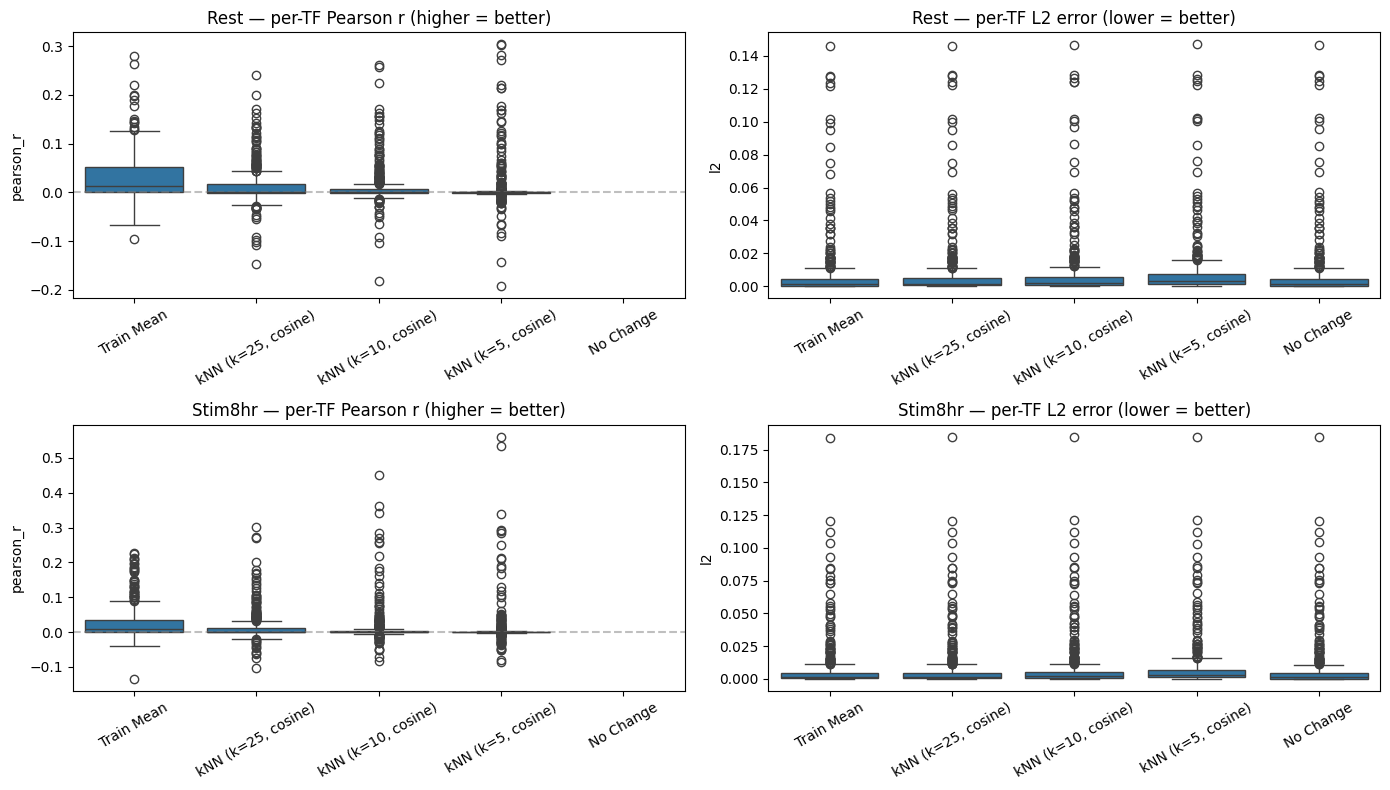

In [22]:
# Faceted boxplots — one row per state, Pearson r left, L2 right
fig, axes = plt.subplots(len(STATES), 2, figsize=(14, 4 * len(STATES)))
if len(STATES) == 1:
    axes = axes[np.newaxis, :]

for row, state in enumerate(STATES):
    state_df = results_df[results_df['state'] == state]
    order = (state_df.groupby('model')['pearson_r'].median()
             .sort_values(ascending=False).index.tolist())

    sns.boxplot(data=state_df, x='model', y='pearson_r', order=order, ax=axes[row, 0])
    axes[row, 0].set_title(f'{state} — per-TF Pearson r (higher = better)')
    axes[row, 0].set_xlabel('')
    axes[row, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[row, 0].tick_params(axis='x', rotation=30)

    sns.boxplot(data=state_df, x='model', y='l2', order=order, ax=axes[row, 1])
    axes[row, 1].set_title(f'{state} — per-TF L2 error (lower = better)')
    axes[row, 1].set_xlabel('')
    axes[row, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cv_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

### Reading these plots

Sanity checks (per state):
- **No Change** → Pearson r ≈ 0, highest L2.
- **Train Mean** → slightly above No Change, lower L2.
- **kNN with random embeddings** → should match Train Mean. Higher means there's a bug.
- **kNN with real embeddings** (after swap) → should beat Train Mean. Gap = signal in embeddings.

If Rest and Stim8hr show very different performance, that's interesting on its own.
Activation states may be inherently harder to predict, or one may have noisier ground truth.

---
## 7. Predict unseen TFs for each state

After benchmarking, retrain on ALL ground-truth TFs per state and predict the unseen TFs.

**Only meaningful after replacing random embeddings with real ones.**

In [23]:
BEST_K       = 10           # adjust based on summary table above
BEST_WEIGHTS = 'distance'
BEST_METRIC  = 'cosine'
LOGFC_THRESHOLD = 0.5       # match perturb-net's |log2FC| > 0.5

def predict_unseen_for_state(state, Y, emb, k, weights, metric):
    shared_tfs = sorted(set(Y.index) & set(emb.index))
    unseen_with_emb = sorted((set(ALL_TFS) - set(Y.index)) & set(emb.index))

    X_pool = emb.loc[shared_tfs].values
    Y_pool = Y.loc[shared_tfs].values
    X_unseen = emb.loc[unseen_with_emb].values

    m = KNeighborsRegressor(n_neighbors=k, weights=weights, metric=metric, n_jobs=-1)
    m.fit(X_pool, Y_pool)
    Y_unseen_pred = m.predict(X_unseen)

    pred_wide = pd.DataFrame(Y_unseen_pred, index=unseen_with_emb, columns=Y.columns)
    pred_wide.to_csv(os.path.join(OUT_DIR, f'knn_predicted_unseen_TFs_wide_{state}.csv'))

    # Long-format edges, thresholded to match perturb-net schema
    edges = []
    for tf in pred_wide.index:
        row = pred_wide.loc[tf]
        sig = row[row.abs() > LOGFC_THRESHOLD]
        for target, logfc in sig.items():
            edges.append({'source_TF': tf, 'target_gene': target, 'log2FC': logfc,
                          'culture_condition': state, 'evidence': 'kNN_predicted'})
    edges_df = pd.DataFrame(edges)
    edges_df.to_csv(os.path.join(OUT_DIR, f'knn_predicted_net_edges_{state}.csv'), index=False)
    print(f'[{state}] Predicted for {len(unseen_with_emb)} TFs → '
          f'{edges_df.shape[0]} edges (|log2FC| > {LOGFC_THRESHOLD})')
    return pred_wide, edges_df

pred_by_state, edges_by_state = {}, {}
for state in STATES:
    pred_wide, edges_df = predict_unseen_for_state(
        state, Y_by_state[state], emb, BEST_K, BEST_WEIGHTS, BEST_METRIC)
    pred_by_state[state] = pred_wide
    edges_by_state[state] = edges_df

[Rest] Predicted for 1230 TFs → 1538 edges (|log2FC| > 0.5)
[Stim8hr] Predicted for 1210 TFs → 1724 edges (|log2FC| > 0.5)


---
## 8. Outputs summary

Saved to `OUT_DIR`:

- `tnet_tier1_CD4_rest.csv`, `tnet_tier1_CD4_act.csv` — T-net Tier 1 (3-way intersection)
- `cv_results_long.csv` — every (state, fold, model, TF) row
- `cv_summary.csv` — median Pearson r and L2 per (state, model)
- `cv_boxplots.png` — Cole-style figure, one row per state
- `knn_predicted_unseen_TFs_wide_Rest.csv`, `..._Stim8hr.csv` — TF × gene log2FC predictions
- `knn_predicted_net_edges_Rest.csv`, `..._Stim8hr.csv` — long-format edges matching perturb-net schema

## Next steps

1. **Swap in STRING embeddings** (cell 3.2). Top performer in Cole et al.
2. **Add ESM2 and GenePT** as alternative embedding sources; compare side-by-side.
3. **Soft validation**: for unseen TFs, check whether kNN-predicted edges overlap with
   pySCENIC-net and scPRINT-net edges for those same TFs. No Perturb-seq ground truth
   exists for these TFs, so this overlap is the validation.
4. **Build full perturb-net + Tier 2/3 T-net layers**: concatenate experimental edges
   (from `..._filtered.csv` files) with `knn_predicted_net_edges_{state}.csv`, with
   `evidence` distinguishing 'experimental' from 'kNN_predicted'.
5. **Optional**: re-add Stim48hr by appending it to `PERTURB_NET_FILES` in cell 0.2.